## **HOMEWORK 3: SUPERVISED LEARNING**

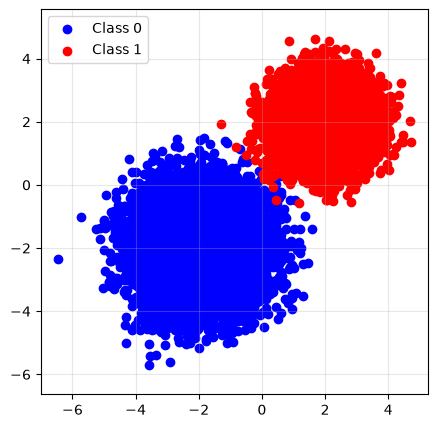

=== Exercise 1: GD Logistic Regression ===
Learned Theta: [-0.2889  1.9096  1.9385]
Final BCE loss: 0.006736
Final accuracy: 99.90%


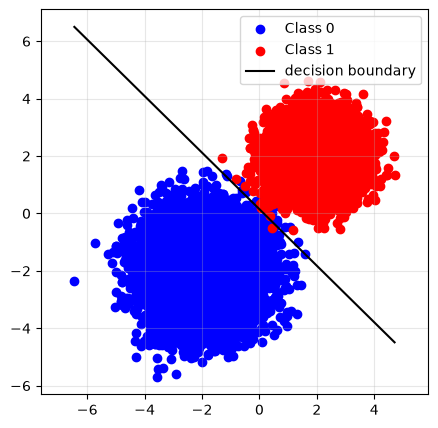

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 1: Logistic Regression on a Toy 2D Dataset
np.random.seed(0)
N = 10000
X0 = np.random.normal(loc=[-2,-2], scale=np.sqrt(1.0), size=(N,2))
y0 = np.zeros((N,1))
X1 = np.random.normal(loc=[2,2], scale=np.sqrt(0.5), size=(N,2))
y1 = np.ones((N,1))
X = np.vstack([X0, X1])
y = np.vstack([y0, y1])
X = np.hstack([np.ones((X.shape[0], 1)), X])

plt.figure(figsize=(5,5))
plt.scatter(X0[:,0], X0[:,1], c="blue", label="Class 0")
plt.scatter(X1[:,0], X1[:,1], c="red",  label="Class 1")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

def sigmoid(z):
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))

def l(theta, X, y):
    p = sigmoid(X @ theta)
    p = np.clip(p, 1e-12, 1-(1e-12))
    return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

def grad_l(theta, X, y):
    p = sigmoid(X @ theta)
    return (X.T @ (p - y)) / len(y)

def GD(l, grad_l, Theta0, X, Y, lr=0.1, epochs=30):
    thetas = [Theta0.copy()]
    theta = Theta0.copy()
    losses = [l(theta, X, Y)]
    for k in range(epochs):
        theta = theta - lr * grad_l(theta, X, Y)
        thetas.append(theta.copy())
        losses.append(l(theta, X, Y))
    return np.array(thetas), np.array(losses)

Theta0 = np.zeros((X.shape[1], 1))
thetas, losses = GD(l, grad_l, Theta0, X, y, lr=0.1, epochs=1000)
Theta_hat = thetas[-1]

preds = (sigmoid(X @ Theta_hat) >= 0.5).astype(int)
acc = np.mean(preds == y)

print("=== Exercise 1: GD Logistic Regression ===")
print(f"Learned Theta: {Theta_hat.ravel().round(4)}")
print(f"Final BCE loss: {losses[-1]:.6f}")
print(f"Final accuracy: {acc*100:.2f}%")

theta0, theta1, theta2 = Theta_hat.ravel()
x1_vals = np.linspace(min(X0[:,0].min(), X1[:,0].min()),
                      max(X0[:,0].max(), X1[:,0].max()), 100)
x2_vals = -(theta0 + theta1 * x1_vals) / theta2

plt.figure(figsize=(5,5))
plt.scatter(X0[:,0], X0[:,1], c="blue", label="Class 0")
plt.scatter(X1[:,0], X1[:,1], c="red",  label="Class 1")
plt.plot(x1_vals, x2_vals, "k-", label="decision boundary")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 2: SGD on Logistic Regression
np.random.seed(0)
N = 10000
X0 = np.random.normal(loc=[-2,-2], scale=np.sqrt(1.0), size=(N,2))
y0 = np.zeros((N,1))
X1 = np.random.normal(loc=[2,2], scale=np.sqrt(0.5), size=(N,2))
y1 = np.ones((N,1))
X = np.vstack([X0, X1])
y = np.vstack([y0, y1])
X = np.hstack([np.ones((X.shape[0], 1)), X])

def sigmoid(z):
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))

def l(theta, X, y):
    p = sigmoid(X @ theta)
    p = np.clip(p, 1e-12, 1-(1e-12))
    return -np.mean(y*np.log(p) + (1-y)*np.log(1-p))

def grad_l(theta, X, y):
    p = sigmoid(X @ theta)
    return (X.T @ (p - y)) / len(y)

def accuracy(theta, X, y):
    preds = sigmoid(X @ theta) >= 0.5
    return np.mean(preds == y)

def SGD(l, grad_l, Theta0, X, Y, batch_size=32, lr=0.1, epochs=100):
    losses = [l(Theta0, X, Y)]
    accs   = [accuracy(Theta0, X, Y)]
    Theta  = Theta0.copy()
    thetas = [Theta.copy()]
    N = X.shape[0]
    for epoch in range(epochs):
        indices = np.random.permutation(N)
        for start in range(0, N, batch_size):
            batch_idx = indices[start:start+batch_size]
            Xb = X[batch_idx]
            Yb = Y[batch_idx]
            Theta = Theta - lr * grad_l(Theta, Xb, Yb)
        losses.append(l(Theta, X, Y))
        thetas.append(Theta.copy())
        accs.append(accuracy(Theta, X, Y))
    return np.array(thetas), np.array(losses), np.array(accs)

batch_sizes = [1, 10, N]
results = {}
Theta0  = np.zeros((X.shape[1], 1))

print("=== Exercise 2: SGD Logistic Regression ===")
for b in batch_sizes:
    thetas, losses, accs = SGD(l, grad_l, Theta0, X, y, batch_size=b)
    results[b] = {"losses": losses, "accs": accs, "thetas": thetas}
    # measure loss smoothness: std of epoch-to-epoch loss changes
    delta_loss = np.diff(losses)
    print(f"batch={b:<6}  final_loss={losses[-1]:.4f}  final_acc={accs[-1]*100:.2f}%  "
          f"loss_std={np.std(delta_loss):.5f}")

colors = ["red", "blue", "green"]
plt.figure(figsize=(6,4))
for b, c in zip(batch_sizes, colors):
    plt.plot(results[b]["losses"], label=f"batch={b}", color=c)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs epoch (SGD, different batch sizes)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

for b, c in zip(batch_sizes, colors):
    plt.figure(figsize=(6,4))
    plt.plot(results[b]["accs"], label=f"batch={b}", color=c)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy vs epoch (SGD, batch size = {b}")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Exercise 3: Evaluation Metrics on a Synthetic Dataset
def sigmoid(z):
    return np.where(z >= 0, 1/(1+np.exp(-z)), np.exp(z)/(1+np.exp(z)))

def eval_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold)
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    acc  = (TP + TN) / (TP + TN + FP + FN)
    prec = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0.0
    return TP, FP, FN, TN, acc, prec, rec, f1

def plot_confusion_matrix(ax, TP, FP, FN, TN, title=""):
    cm = np.array([[TN, FP], [FN, TP]])
    ax.imshow(cm, cmap="Blues")
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]}",
                    ha="center", va="center", fontsize=11,
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["Actual 0", "Actual 1"])
    ax.set_title(title)

y_prob = sigmoid(X @ Theta_hat)
thresholds = [0.3, 0.5, 0.7]

print("=== Exercise 3: Classification Metrics ===")
print(f"{'Threshold':<12} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>6}  {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, thr in zip(axes, thresholds):
    TP, FP, FN, TN, acc, prec, rec, f1 = eval_metrics(y, y_prob, thr)
    print(f"{thr:<12} {TP:>6} {FP:>6} {FN:>6} {TN:>6}  {acc:>6.4f} {prec:>6.4f} {rec:>6.4f} {f1:>6.4f}")
    plot_confusion_matrix(ax, TP, FP, FN, TN,
                          title=f"threshold = {thr}\nAcc={acc:.4f}  F1={f1:.4f}")

fig.suptitle("Confusion matrices for different thresholds", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

BATCH_SIZE = 32
LR         = 1e-3
EPOCHS     = 200

# Exercise 4: Logistic Regression on the Diabetes Dataset
df = pd.read_csv("diabetes.csv")
X = df.drop("Outcome", axis=1).values
Y = df["Outcome"].values.reshape(-1,1)
print(df.head())
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features  |  class balance: {Y.mean()*100:.1f}% positive")
X = (X - X.mean(axis=0)) / X.std(axis=0)
X = np.hstack([np.ones((X.shape[0], 1)), X])
N, d = X.shape

def sigmoid(z):
    return 1/(1+np.exp(-z))

def l(theta, X, y):
    p = np.clip(sigmoid(X @ theta), 1e-12, 1-1e-12)
    return -(y*np.log(p) + (1-y)*np.log(1-p)).mean()

def grad_l(theta, X, y):
    return (X.T @ (sigmoid(X @ theta) - y)) / len(y)

def accuracy(theta, X, y):
    return ((sigmoid(X @ theta) >= 0.5) == y).mean()

def SGD(l, grad_l, Theta0, X, y, batch_size=BATCH_SIZE, lr=LR, epochs=EPOCHS):
    N = X.shape[0]
    theta = Theta0.copy()
    losses = [l(theta, X, y)]
    accs = [accuracy(theta, X, y)]
    for epoch in range(epochs):
        for idx in np.array_split(np.random.permutation(N), max(1, N//batch_size)):
            theta -= lr * grad_l(theta, X[idx], y[idx])
        losses.append(l(theta, X, y))
        accs.append(accuracy(theta, X, y))
    return theta, np.array(losses), np.array(accs)

def train_adam(l, grad_l, X, y, lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE,
               beta1=0.9, beta2=0.999, eps=1e-8):
    N, d = X.shape
    theta = np.zeros((d,1))
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    t = 0
    losses, accs = [], []
    for epoch in range(epochs):
        for idx in np.array_split(np.random.permutation(N), max(1, N//batch_size)):
            g = grad_l(theta, X[idx], y[idx])
            t += 1
            m = beta1*m + (1-beta1)*g
            v = beta2*v + (1-beta2)*(g*g)
            theta -= lr * (m/(1-beta1**t)) / (np.sqrt(v/(1-beta2**t)) + eps)
        losses.append(l(theta, X, y))
        accs.append(accuracy(theta, X, y))
    return theta, np.array(losses), np.array(accs)

def eval_metrics(theta, X, y, threshold=0.5):
    p = sigmoid(X @ theta)
    yp = (p >= threshold).astype(int)
    yt = y.astype(int)
    TP = np.sum((yt==1)&(yp==1))
    FP = np.sum((yt==0)&(yp==1))
    FN = np.sum((yt==1)&(yp==0))
    TN = np.sum((yt==0)&(yp==0))
    acc  = (TP+TN)/(TP+TN+FP+FN)
    prec = TP/(TP+FP) if (TP+FP)>0 else 0.0
    rec  = TP/(TP+FN) if (TP+FN)>0 else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    return TP, FP, FN, TN, acc, prec, rec, f1

def plot_confusion_matrix(ax, TP, FP, FN, TN, title=""):
    cm = np.array([[TN, FP], [FN, TP]])
    ax.imshow(cm, cmap="Blues")
    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]}",
                    ha="center", va="center", fontsize=11,
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["Actual 0", "Actual 1"])
    ax.set_title(title)

Theta0 = np.zeros((d,1))
np.random.seed(0)
Theta_sgd, losses_sgd, accs_sgd   = SGD(l, grad_l, Theta0, X, Y)
np.random.seed(0)
theta_adam, losses_adam, accs_adam = train_adam(l, grad_l, X, Y)

print("\n=== Exercise 4: SGD vs Adam on Diabetes Dataset ===")
print(f"{'Method':<8} {'Final Loss':>12} {'Final Acc':>10} {'Prec':>7} {'Rec':>7} {'F1':>7}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, (name, th, loss, acc_arr) in zip(axes, [
        ("SGD",  Theta_sgd,  losses_sgd,  accs_sgd),
        ("Adam", theta_adam, losses_adam, accs_adam)]):
    TP, FP, FN, TN, acc, prec, rec, f1 = eval_metrics(th, X, Y)
    print(f"{name:<8} {loss[-1]:>12.6f} {acc_arr[-1]*100:>9.2f}%  {prec:>6.4f}  {rec:>6.4f}  {f1:>6.4f}")
    print(f"         Confusion: TP={TP} FP={FP} FN={FN} TN={TN}")
    plot_confusion_matrix(ax, TP, FP, FN, TN,
                          title=f"{name}\nAcc={acc:.4f}  F1={f1:.4f}")
fig.suptitle("Confusion matrices, SGD vs Adam")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"SGD vs Adam on Diabetes Dataset (batch={BATCH_SIZE}, lr={LR}, epochs={EPOCHS})", fontsize=13)

axes[0, 0].plot(losses_sgd, label="SGD", color="red")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("BCE loss")
axes[0, 0].set_title("Loss vs Epoch (SGD)")
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(accs_sgd, label="SGD", color="red")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Accuracy vs Epoch (SGD)")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(losses_sgd, label="SGD", color="red")
axes[1, 0].plot(losses_adam, label="Adam", color="blue")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("BCE loss")
axes[1, 0].set_title("Loss vs Epoch (SGD vs Adam)")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].plot(accs_sgd, label="SGD", color="red")
axes[1, 1].plot(accs_adam, label="Adam", color="blue")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Accuracy vs Epoch (SGD vs Adam)")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()
